# Perception Model — Human Activity Recognition (HAR) Dataset

This notebook loads the **UCI HAR Dataset** from `datasets/perception_dataset`, we then train five machine learning models and compare their performance. (Mainly SVM, Random Forest, KNN, Logistic Regression, and Neural Network)

**Dataset Summary:**
- 30 Subjects wearing a Samsung Galaxy S II
- 6 Activities: WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING
- 561 features extracted from accelerometer & gyroscope signals at 50 Hz
- Train / Test split: 70% / 30%

## 1. Imports & Configuration

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


## 2. Load the Dataset

In [ ]:
BASE_DIR  = os.path.join('..', 'robot-intelligence-dataset', 'perception_dataset')
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

# Load feature names
features_df   = pd.read_csv(os.path.join(BASE_DIR, 'features.txt'), sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features_df['feature'].tolist()

# De-duplicate feature names
seen = {}
unique_features = []
for f in feature_names:
    if f in seen:
        seen[f] += 1
        unique_features.append(f'{f}_{seen[f]}')
    else:
        seen[f] = 0
        unique_features.append(f)

# Load activity labels
activity_labels = pd.read_csv(os.path.join(BASE_DIR, 'activity_labels.txt'), sep=r'\s+', header=None, names=['id', 'activity'])
id_to_activity  = dict(zip(activity_labels['id'], activity_labels['activity']))

# Load train split
X_train = pd.read_csv(os.path.join(TRAIN_DIR, 'X_train.txt'), sep=r'\s+', header=None, names=unique_features)
y_train = pd.read_csv(os.path.join(TRAIN_DIR, 'y_train.txt'), sep=r'\s+', header=None, names=['activity_id'])

# Load test split
X_test  = pd.read_csv(os.path.join(TEST_DIR, 'X_test.txt'),  sep=r'\s+', header=None, names=unique_features)
y_test = pd.read_csv(os.path.join(TEST_DIR, 'y_test.txt'),  sep=r'\s+', header=None, names=['activity_id'])

# Load subject IDs
subj_train  = pd.read_csv(os.path.join(TRAIN_DIR, 'subject_train.txt'), sep=r'\s+', header=None, names=['subject'])
subj_test   = pd.read_csv(os.path.join(TEST_DIR,  'subject_test.txt'),  sep=r'\s+', header=None, names=['subject'])

# Build tidy DataFrames
train_df = X_train.copy()
train_df['activity_id'] = y_train['activity_id'].values
train_df['activity']    = train_df['activity_id'].map(id_to_activity)
train_df['subject']     = subj_train['subject'].values
train_df['split']       = 'train'

test_df = X_test.copy()
test_df['activity_id'] = y_test['activity_id'].values
test_df['activity']    = test_df['activity_id'].map(id_to_activity)
test_df['subject']     = subj_test['subject'].values
test_df['split']       = 'test'

df = pd.concat([train_df, test_df], ignore_index=True)

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
print(f'Full  shape : {df.shape}')
print(f"Activities  : {df['activity'].unique().tolist()}")
print(f"Subjects    : {sorted(df['subject'].unique().tolist())}")


Train shape : (7352, 565)
Test  shape : (2947, 565)
Full  shape : (10299, 565)
Activities  : ['STANDING', 'SITTING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
Subjects    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


## 3. Dataset Overview

In [18]:
# ── Input Features ─────────────────────────────────────────────────────────
print(f"Total input features : {len(unique_features)}")
print(f"\nFirst 10 features:")
for i, f in enumerate(unique_features[:10], 1):
    print(f"  {i:>2}. {f}")

print(f"\nFeature value range  : [{X_train.values.min():.3f}, {X_train.values.max():.3f}]")
print(f"\nSample of X_train (first 3 rows, first 5 features):")
print(X_train.iloc[:3, :5].to_string())

# ── Labels ─────────────────────────────────────────────────────────────────
print(f"\n\nActivity Labels:")
for aid, name in id_to_activity.items():
    count = (y_train['activity_id'] == aid).sum()
    print(f"  {aid}  {name:<22}  {count} samples")

print(f"\nSample of y_train (first 10):")
print(y_train['activity_id'].map(id_to_activity).head(10).to_string())

Total input features : 561

First 10 features:
   1. tBodyAcc-mean()-X
   2. tBodyAcc-mean()-Y
   3. tBodyAcc-mean()-Z
   4. tBodyAcc-std()-X
   5. tBodyAcc-std()-Y
   6. tBodyAcc-std()-Z
   7. tBodyAcc-mad()-X
   8. tBodyAcc-mad()-Y
   9. tBodyAcc-mad()-Z
  10. tBodyAcc-max()-X

Feature value range  : [-1.000, 1.000]

Sample of X_train (first 3 rows, first 5 features):
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  tBodyAcc-std()-Y
0           0.288585          -0.020294          -0.132905         -0.995279         -0.983111
1           0.278419          -0.016411          -0.123520         -0.998245         -0.975300
2           0.279653          -0.019467          -0.113462         -0.995380         -0.967187


Activity Labels:
  1  WALKING                 1226 samples
  2  WALKING_UPSTAIRS        1073 samples
  3  WALKING_DOWNSTAIRS      986 samples
  4  SITTING                 1286 samples
  5  STANDING                1374 samples
  6  LAYING        

In [19]:
print('=== First 5 rows (meta columns only) ===')
display(df[['subject', 'activity', 'split'] + unique_features[:5]].head())

print('\n=== Basic Statistics (first 10 features) ===')
display(df[unique_features[:10]].describe().round(3))

print('\n=== Missing values ===')
print(df.isnull().sum().sum(), 'missing values in total')

=== First 5 rows (meta columns only) ===


,subject,activity,split,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y
0,1,STANDING,train,0.288585,-0.020294,-0.132905,-0.995279,-0.983111
1,1,STANDING,train,0.278419,-0.016411,-0.123520,-0.998245,-0.975300
2,1,STANDING,train,0.279653,-0.019467,-0.113462,-0.995380,-0.967187
3,1,STANDING,train,0.279174,-0.026201,-0.123283,-0.996091,-0.983403
4,1,STANDING,train,0.276629,-0.016570,-0.115362,-0.998139,-0.980817



=== Basic Statistics (first 10 features) ===


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X
count,10299.000,10299.000,10299.000,10299.000,10299.000,10299.000,10299.000,10299.000,10299.000,10299.000
mean,0.274,-0.018,-0.109,-0.608,-0.510,-0.613,-0.634,-0.526,-0.615,-0.467
std,0.068,0.037,0.053,0.439,0.500,0.404,0.413,0.484,0.399,0.539
min,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000
25%,0.263,-0.025,-0.121,-0.992,-0.977,-0.979,-0.993,-0.977,-0.979,-0.936
50%,0.277,-0.017,-0.109,-0.943,-0.835,-0.851,-0.948,-0.844,-0.845,-0.875
75%,0.288,-0.011,-0.098,-0.250,-0.057,-0.279,-0.302,-0.087,-0.288,-0.015
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000



=== Missing values ===
0 missing values in total


## 4. Data Preprocessing

4.1  Data quality check

In [20]:
assert df[unique_features].isnull().sum().sum() == 0, 'Missing values found!'
assert df.duplicated(subset=unique_features).sum() == 0, 'Duplicate rows found!'
print('No missing values or duplicate rows.')
print(f'Feature range: [{df[unique_features].min().min():.3f}',
    f'{df[unique_features].max().max():.3f}]  (already normalised to [-1, 1])')

No missing values or duplicate rows.
Feature range: [-1.000 1.000]  (already normalised to [-1, 1])


4.2 Encode activity labels

In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
le.fit(df['activity'])
print('Label encoding:')
for name, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {idx}  ->  {name}')

Label encoding:
  0  ->  LAYING
  1  ->  SITTING
  2  ->  STANDING
  3  ->  WALKING
  4  ->  WALKING_DOWNSTAIRS
  5  ->  WALKING_UPSTAIRS


4.3  Build X / y arrays and scale features

In [22]:
X_train = train_df[unique_features].values
X_test  = test_df[unique_features].values
y_train = le.transform(train_df['activity'])
y_test  = le.transform(test_df['activity'])

# Fit scaler only on train to avoid data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'y_train : {y_train.shape}   y_test : {y_test.shape}') 
print(f'\nPost-scaling mean : {X_train.mean():.4f}  (expected ~0)')
print(f'Post-scaling std  : {X_train.std():.4f}  (expected ~1)')
print('\nPreprocessing complete — X_train / X_test / y_train / y_test are ready.')

X_train : (7352, 561)   X_test : (2947, 561)
y_train : (7352,)   y_test : (2947,)

Post-scaling mean : 0.0000  (expected ~0)
Post-scaling std  : 1.0000  (expected ~1)

Preprocessing complete — X_train / X_test / y_train / y_test are ready.


## 5. Training and Testing the Models

In [23]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

models = {
    "SVM":                 SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "KNN":                 KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Neural Network":      MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                                         random_state=42, early_stopping=True),
}

results = {}
print(f"{'Model':<22}  {'Train Acc':>10}  {'Test Acc':>10}  {'Time (s)':>10}")
print("-" * 58)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    results[name] = {"model": model, "train_acc": train_acc, "test_acc": test_acc}

    print(f"{name:<22}  {train_acc:>10.4f}  {test_acc:>10.4f}  {elapsed:>10.1f}")

Model                    Train Acc    Test Acc    Time (s)
----------------------------------------------------------
SVM                         0.9981      0.9542         0.9
Random Forest               1.0000      0.9291         2.2
KNN                         0.9785      0.8887         0.0
Logistic Regression         0.9962      0.9549         2.2
Neural Network              0.9990      0.9450        13.9


## 7. Results Overview and Comparison

Classification report for the best model

In [24]:
best_name = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['model']
y_pred = best_model.predict(X_test)

print(f"Best model: {best_name}  (test acc = {results[best_name]['test_acc']:.4f})\\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Best model: Logistic Regression  (test acc = 0.9549)\n
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      0.99       537
           SITTING       0.97      0.88      0.92       491
          STANDING       0.89      0.97      0.93       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
  WALKING_UPSTAIRS       0.96      0.95      0.95       471

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



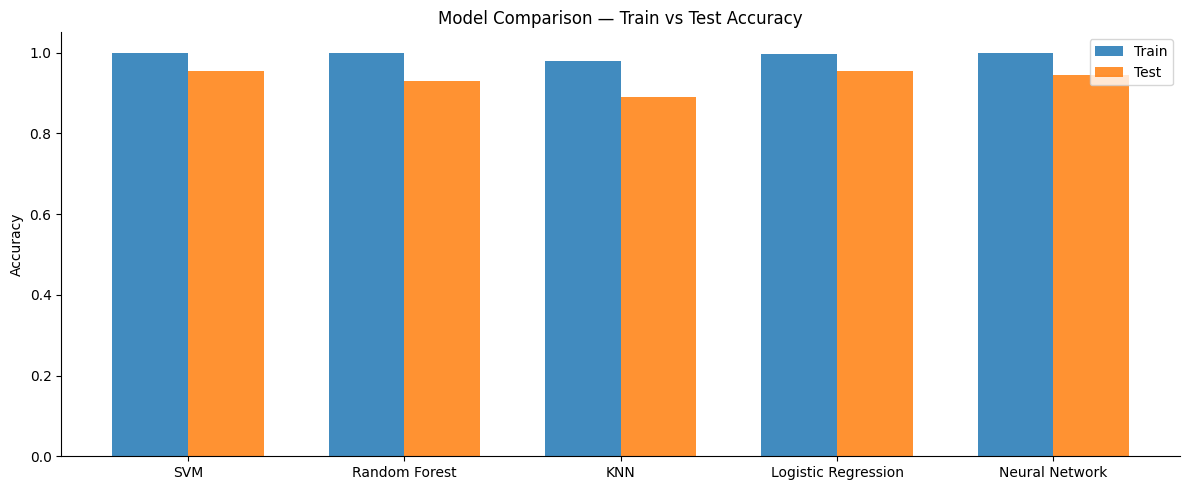

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

names      = list(results.keys())
test_accs  = [results[n]['test_acc']  for n in names]
train_accs = [results[n]['train_acc'] for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - w/2, train_accs, w, label='Train', alpha=0.85)
ax.bar(x + w/2, test_accs,  w, label='Test', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Train vs Test Accuracy')
ax.spines[['top', 'right']].set_visible(False)

ax.legend()

plt.tight_layout()
plt.show()

## 7. PCA Feature Reduction

In [26]:
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# Reduce to 95 % explained variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f"Original features : {X_train.shape[1]}")
print(f"After PCA (95 %)  : {X_train_pca.shape[1]}")
print(f"Variance retained : {pca.explained_variance_ratio_.sum()*100:.1f}%")


Original features : 561
After PCA (95 %)  : 102
Variance retained : 95.1%


Compare accuracy with and without PCA

In [27]:
print(f"{'Model':<22}  {'No PCA':>10}  {'With PCA':>10}")
print("-" * 48)

pca_results = {}
for name, model in models.items():
    model_pca = type(model)(**model.get_params())
    model_pca.fit(X_train_pca, y_train)
    acc_pca    = accuracy_score(y_test, model_pca.predict(X_test_pca))
    acc_no_pca = results[name]['test_acc']
    pca_results[name] = acc_pca
    print(f"{name:<22}  {acc_no_pca:>10.4f}  {acc_pca:>10.4f}")


Model                       No PCA    With PCA
------------------------------------------------
SVM                         0.9542      0.9410
Random Forest               0.9291      0.8863
KNN                         0.8887      0.8812
Logistic Regression         0.9549      0.9308
Neural Network              0.9450      0.9328


## 8. Confusion Matrix — Best Model

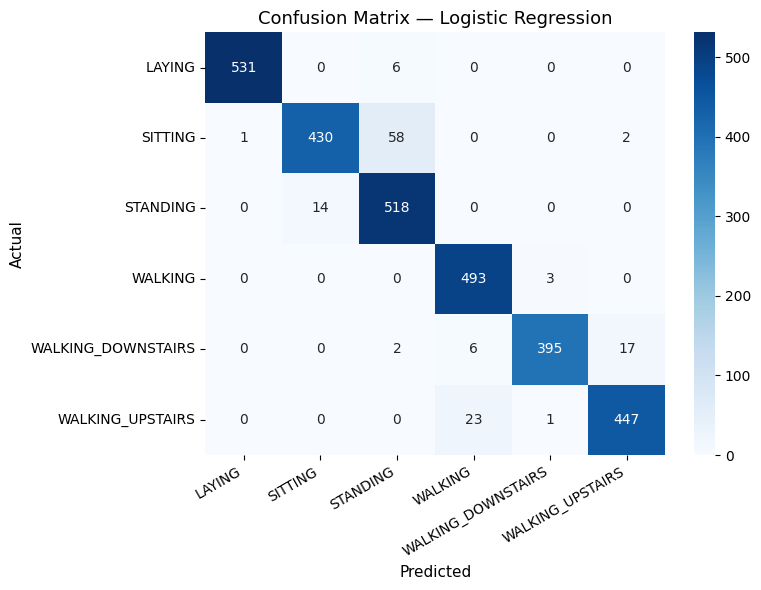

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_name  = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['model']
y_pred     = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
labels = le.classes_

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 9. Feature Importance — Random Forest

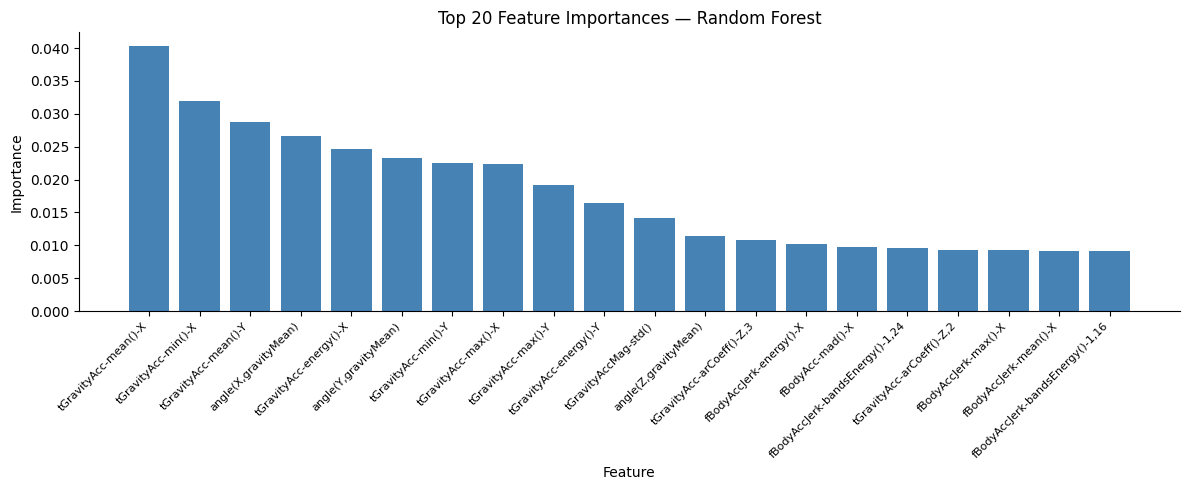

In [29]:
rf_model    = results['Random Forest']['model']
importances = rf_model.feature_importances_
indices     = importances.argsort()[::-1][:20]
top_names   = [unique_features[i] for i in indices]
top_vals    = importances[indices]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(20), top_vals, color='steelblue', edgecolor='none')
ax.set_xticks(range(20))
ax.set_xticklabels(top_names, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.set_title('Top 20 Feature Importances — Random Forest')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## 10. Cross-Validation (5-Fold)

In [30]:
from sklearn.model_selection import cross_val_score

print(f"{'Model':<22}  {'CV Mean':>10}  {'CV Std':>10}")
print("-" * 46)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    print(f"{name:<22}  {scores.mean():>10.4f}  {scores.std():>10.4f}")


Model                      CV Mean      CV Std
----------------------------------------------
SVM                         0.9302      0.0184
Random Forest               0.9188      0.0157
KNN                         0.8751      0.0117
Logistic Regression         0.9350      0.0245
Neural Network              0.9290      0.0249
